# C2 HGP code X-noise Monte Carlo for BP-OSD-0

This notebook is set up to reproduce the **BP-OSD-0** curve in **Figure 3** of
[*Sequential BP-based Decoding of QLDPC Codes*](https://arxiv.org/abs/2602.13420) for the fixed hypergraph-product code:

- `C2 = [[1922,50,16]]`

Noise model:

- **independent X noise**
- each qubit receives `X` with probability `p_x`

Decoder:

- **BP+OSD-0** implemented through `bp_osd_cs_decode(...; osd_order=0)`
- binary CSS decoding of the `X` sector only, using syndrome `s_x = H_Z * x (mod 2)`

For the X-only code-capacity model, a trial is counted as a failure iff the residual
X error is nontrivial modulo the X-stabilizer group.

In [26]:
using Plots
using Distributed
using LinearAlgebra
using JLD2

num_cores = length(Sys.cpu_info())
if nprocs() == 1
    addprocs(num_cores; exeflags=`--project=$(Base.active_project())`)
end

@everywhere begin
    using LatticeAlgorithms
    using LinearAlgebra
    using Dates
    using SparseArrays
    using Random
    using Statistics
end

## Build the fixed HGP code `C2 = [[1922,50,16]]`

This follows the package helper you added for the conventional hypergraph-product
example from the literature.

In [27]:
H_parent = LatticeAlgorithms.panteleev_kalachev_c2_parent_check_matrix()
HX, HZ = LatticeAlgorithms.hgp_check_matrices(H_parent, H_parent)
params = LatticeAlgorithms.hgp_parameters(H_parent, H_parent; compute_distance=false)

println("Constructed parameters:")
println(params)
println("size(HX) = ", size(HX))
println("size(HZ) = ", size(HZ))
println("commutation check = ", all(iszero, mod.(HX * transpose(HZ), 2)))

# For X-noise on a CSS code, decode with HZ.
Hdec = Matrix{Int64}(HZ)
n = size(Hdec, 2)
println("n = ", n)

Constructed parameters:
(n = 1922, k = 50)
size(HX) = (961, 1922)
size(HZ) = (961, 1922)
commutation check = true
n = 1922


## Helpers

Keep this close to the BB tutorial pattern: define the per-shot simulator once,
then map it in parallel over many shots.

In [28]:
@everywhere begin
    function sample_x_error(n::Int, px::Real, rng::AbstractRNG)
        return Int64.(rand(rng, n) .< px)
    end

    function gf2_rowspace_contains(H::AbstractMatrix{<:Integer}, v::AbstractVector{<:Integer})
        H2 = mod.(Int64.(H), 2)
        v2 = mod.(Int64.(v), 2)

        if size(H2, 2) != length(v2)
            error("Dimension mismatch in gf2_rowspace_contains.")
        end

        _, piv1 = LatticeAlgorithms.gf2_rref(H2)
        _, piv2 = LatticeAlgorithms.gf2_rref(vcat(H2, reshape(v2, 1, :)))
        return length(piv1) == length(piv2)
    end

    function x_frame_error_indicator(
        HX::AbstractMatrix{<:Integer},
        x_true::AbstractVector{<:Integer},
        x_hat::AbstractVector{<:Integer},
    )
        residual = mod.(Int64.(x_true) .+ Int64.(x_hat), 2)
        return gf2_rowspace_contains(HX, residual) ? 0 : 1
    end

    function run_bp_osd0_trial(
        HX::AbstractMatrix{<:Integer},
        Hdec::AbstractMatrix{<:Integer},
        px::Real,
        seed::Int,
    )
        rng = MersenneTwister(seed)
        n = size(Hdec, 2)

        x_true = sample_x_error(n, px, rng)
        sx = mod.(Hdec * x_true, 2)

        dec = LatticeAlgorithms.bp_osd_cs_decode(
            Hdec,
            sx,
            px;
            max_iter=100,
            osd_order=0,
            check_to_bit_update_rule=:min_sum,
            bit_to_check_update_rule=:memoryless,
            min_sum_scaling=:roffe,
        )

        fer = x_frame_error_indicator(HX, x_true, dec.error)

        return (
            fer=fer,
            bp_converged=dec.converged ? 1 : 0,
        )
    end
end

## Monte Carlo benchmark

This is the part that should feel closest to your BB notebook:
- choose a grid of physical error rates,
- distribute many shots across workers,
- aggregate FER and uncertainty.

In [29]:
px_vec = collect(0.04:0.01:0.10)
num_shots = 200
base_seed = 1234

results = NamedTuple[]

for (ip, px) in enumerate(px_vec)
    println("Running p_x = ", px)

    trials = pmap(1:num_shots) do shot
        run_bp_osd0_trial(HX, Hdec, px, base_seed + 10_000 * ip + shot)
    end

    fer_samples = [t.fer for t in trials]
    bp_conv_samples = [t.bp_converged for t in trials]

    fer_hat = mean(fer_samples)
    fer_se = sqrt(max(fer_hat * (1 - fer_hat) / num_shots, 0.0))
    bp_conv_hat = mean(bp_conv_samples)

    push!(results, (
        px=px,
        fer=fer_hat,
        fer_se=fer_se,
        bp_converged_rate=bp_conv_hat,
        num_shots=num_shots,
    ))

    println("  FER = $fer_hat ± $fer_se, BP-converged rate = $bp_conv_hat")
end

results

Running p_x = 0.04


  FER = 0.02 ± 0.009899494936611665, BP-converged rate = 0.895
Running p_x = 0.05
  FER = 0.025 ± 0.011039701082909808, BP-converged rate = 0.825
Running p_x = 0.06
  FER = 0.07 ± 0.01804161855266872, BP-converged rate = 0.59
Running p_x = 0.07
  FER = 0.265 ± 0.031206970375222264, BP-converged rate = 0.3
Running p_x = 0.08
  FER = 0.765 ± 0.029981244136960027, BP-converged rate = 0.055
Running p_x = 0.09
  FER = 0.97 ± 0.012062338081814825, BP-converged rate = 0.0
Running p_x = 0.1
  FER = 0.995 ± 0.004987484335815003, BP-converged rate = 0.0


7-element Vector{NamedTuple}:
 (px = 0.04, fer = 0.02, fer_se = 0.009899494936611665, bp_converged_rate = 0.895, num_shots = 200)
 (px = 0.05, fer = 0.025, fer_se = 0.011039701082909808, bp_converged_rate = 0.825, num_shots = 200)
 (px = 0.06, fer = 0.07, fer_se = 0.01804161855266872, bp_converged_rate = 0.59, num_shots = 200)
 (px = 0.07, fer = 0.265, fer_se = 0.031206970375222264, bp_converged_rate = 0.3, num_shots = 200)
 (px = 0.08, fer = 0.765, fer_se = 0.029981244136960027, bp_converged_rate = 0.055, num_shots = 200)
 (px = 0.09, fer = 0.97, fer_se = 0.012062338081814825, bp_converged_rate = 0.0, num_shots = 200)
 (px = 0.1, fer = 0.995, fer_se = 0.004987484335815003, bp_converged_rate = 0.0, num_shots = 200)

## Plot

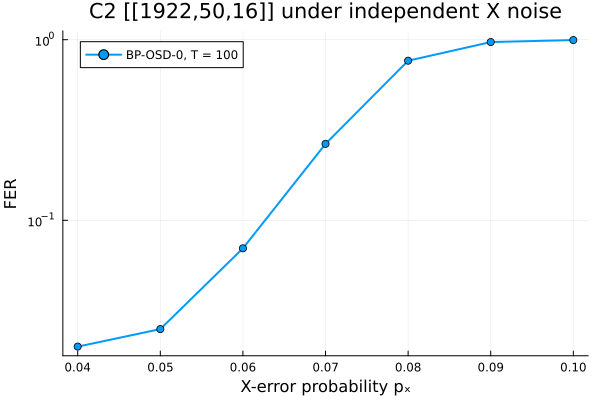

In [30]:
pxs = [r.px for r in results]
fers = [r.fer for r in results]
fer_se = [r.fer_se for r in results]

plt = plot(
    pxs,
    fers;
    yscale=:log10,
    marker=:circle,
    linewidth=2,
    xlabel="X-error probability pₓ",
    ylabel="FER",
    label="BP-OSD-0, T = 100",
    title="C2 [[1922,50,16]] under independent X noise",
)

display(plt)